# Extended Lab: Probability & Non-Probability Sampling

**Based on:** *Building Statistical Models in Python*, Chapter 1 —
"Sampling and Generalization", plus the accompanying
`1_Probability_Sampling.ipynb` and `2_Stratified_Sampling.ipynb` examples.

This lab extends the book's simple-random and stratified-sampling examples
into a full, self-contained study. You will:

1. Build a synthetic population with a **known** ground truth.
2. Implement all four probability sampling strategies from the chapter —
   **simple random, systematic, stratified, cluster** — plus two
   **non-probability** strategies — **convenience, quota**.
3. Run a Monte Carlo comparison to see which methods are biased, which are
   noisy, and why.
4. Preview how a single sample is used to infer a population parameter with
   a confidence interval (bridging into Chapters 2–3 of the book).

Run the cells top to bottom — every cell produces output you can inspect.


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# A single Generator instance, seeded for reproducibility -- same pattern
# used in the book's notebooks (np.random.default_rng).
rng = np.random.default_rng(2020)

pd.set_option("display.max_rows", 10)
plt.rcParams["figure.figsize"] = (7, 4)


## The running example: a field of plants

Throughout this lab we reuse the field-of-plants scenario from *Building
Statistical Models in Python* (Chapter 1). A farmer has a rectangular field
split into three plots — **A**, **B**, and **C**:

- **Plot A** sits next to a forest, so those plants get slightly **less
  sunlight**.
- **Plot B** sits between the primary irrigation lines, so those plants get
  **more water**.
- **Plot C** sits next to a road, so those plants are exposed to **dust and
  runoff**.

These are the *confounding variables* the book describes — real effects that
make one part of the field systematically different from another. Because we
are simulating the field ourselves, we know the **true population mean
yield**. That lets us score every sampling method by how close its estimate
comes to the truth — something you can never do with a real population.


In [2]:
N = 900  # total plants in the field (population size)

# 300 plants per plot, laid out in contiguous blocks A | B | C
plot = np.repeat(["A", "B", "C"], N // 3)

# 30 clusters of 30 plants each (e.g. 10 sub-rows per plot) -- used later
# for cluster sampling.
cluster_id = np.arange(N) // 30 + 1

# Confounding effects described in the book (Figure 1.2)
forest_effect      = np.where(plot == "A", -5.0, 0.0)   # less light near forest
irrigation_effect  = np.where(plot == "B",  8.0, 0.0)   # more water near irrigation
road_effect        = np.where(plot == "C", -2.0, 0.0)   # dust/runoff near road

base_yield = 50.0
noise = rng.normal(0, 6, size=N)

yield_kg = base_yield + forest_effect + irrigation_effect + road_effect + noise

population = pd.DataFrame({
    "plant_id": np.arange(1, N + 1),
    "plot": plot,
    "cluster_id": cluster_id,
    "yield_kg": yield_kg,
})

population.head()


,plant_id,plot,cluster_id,yield_kg
0,1,A,1,52.561240
1,2,A,1,46.339071
2,3,A,1,52.995292
3,4,A,1,36.490772
4,5,A,1,43.363218


### 1.1 Ground truth

Because we generated the data, we can compute the *true* population parameters. Every sampling method below will be judged against these numbers.

In [3]:
POP_MEAN = population["yield_kg"].mean()
POP_STD  = population["yield_kg"].std(ddof=0)

print(f"Population size:        N = {len(population)}")
print(f"Population mean yield:  mu = {POP_MEAN:.3f} kg")
print(f"Population std dev:     sigma = {POP_STD:.3f} kg")

population.groupby("plot")["yield_kg"].agg(["count", "mean", "std"])


Population size:        N = 900
Population mean yield:  mu = 50.211 kg
Population std dev:     sigma = 8.186 kg


,count,mean,std
plot,,,
A,300,44.809676,6.045988
B,300,57.849553,5.855096
C,300,47.974813,6.167083


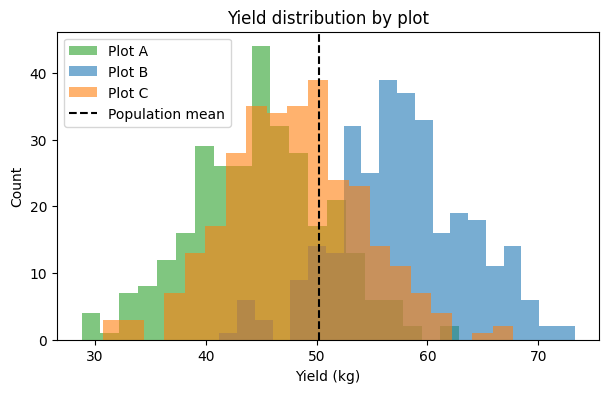

In [4]:
fig, ax = plt.subplots()
for p, color in zip(["A", "B", "C"], ["tab:green", "tab:blue", "tab:orange"]):
    ax.hist(population.loc[population["plot"] == p, "yield_kg"], bins=20,
            alpha=0.6, label=f"Plot {p}", color=color)
ax.axvline(POP_MEAN, color="black", linestyle="--", label="Population mean")
ax.set_xlabel("Yield (kg)")
ax.set_ylabel("Count")
ax.set_title("Yield distribution by plot")
ax.legend()
plt.show()


## 2. Simple random sampling

*Every member of the population has an equal chance of selection* — the
book's Figure 1.4 example, extended from 10 numbered slips of paper to our
900-plant field. This is `random_generator.choice(..., replace=False)`, the
exact call used in `1_Probability_Sampling.ipynb`.


In [5]:
def simple_random_sample(df, n, rng):
    """Simple random sample without replacement."""
    idx = rng.choice(df.index, size=n, replace=False)
    return df.loc[idx]

n = 90  # 10% of the population
srs = simple_random_sample(population, n, rng)

print(f"SRS mean yield (n={n}): {srs['yield_kg'].mean():.3f} kg "
      f"(true mean = {POP_MEAN:.3f})")
srs.groupby("plot").size()


SRS mean yield (n=90): 51.781 kg (true mean = 50.211)


plot
A    25
B    34
C    31
dtype: int64

## 3. Systematic sampling

Pick a random starting point, then take every *k*-th member, where
`k = N // n` is the **sampling interval** (book: 50 students / 10 books = 5).


In [6]:
def systematic_sample(df, n, rng):
    """Systematic sample: random start + fixed interval k = N // n."""
    N = len(df)
    k = N // n
    start = rng.integers(0, k)
    positions = np.arange(start, N, k)[:n]
    return df.iloc[positions]

sys_sample = systematic_sample(population, n, rng)
print(f"Systematic mean yield (n={n}): {sys_sample['yield_kg'].mean():.3f} kg")
sys_sample.groupby("plot").size()


Systematic mean yield (n=90): 49.509 kg


plot
A    30
B    30
C    30
dtype: int64

### 3.1 The hidden risk of systematic sampling

The book warns that systematic sampling is biased **if the population is
already organized in a way that lines up with the sampling interval** (its
example: top students landing on every 10th roll number). Our field is
organized in contiguous plot blocks, so let's see what happens if the
interval *itself* happens to divide evenly by 300 (the plot size).


In [7]:
# Interval that divides the 300-plant plot blocks evenly -> every selected
# plant lands in the same relative spot inside its plot.
k_bad = 300 // 6   # = 50 -> only 6 positions per plot get sampled, repeatedly

def systematic_sample_fixed_k(df, k, start, ):
    N = len(df)
    positions = np.arange(start, N, k)
    return df.iloc[positions]

biased_sys = systematic_sample_fixed_k(population, k=k_bad, start=10)
print(f"Biased systematic sample size: {len(biased_sys)}")
print(f"Biased systematic mean: {biased_sys['yield_kg'].mean():.3f} kg "
      f"(true mean = {POP_MEAN:.3f})")
biased_sys.groupby("plot").size()


Biased systematic sample size: 18
Biased systematic mean: 49.339 kg (true mean = 50.211)


plot
A    6
B    6
C    6
dtype: int64

Notice the sample is still spread evenly across plots (because the field
happens to be laid out as three equal blocks) — but if the *within-plot*
pattern itself had a periodic structure (e.g. every 50th plant sat right next
to the irrigation line), systematic sampling would quietly bake that pattern
into every single sample. This is exactly the "coincidental periodicity"
risk described in the book.


## 4. Stratified sampling

Split the population into homogeneous **strata** (here: plot), then draw an
independent simple random sample from *each* stratum — proportionally to
stratum size. This generalizes `2_Stratified_Sampling.ipynb`'s
number/string strata to plot A/B/C strata with a continuous yield variable.


In [8]:
def stratified_sample(df, strata_col, frac, rng):
    """Proportional stratified sample: draw `frac` of each stratum."""
    parts = []
    for level, group in df.groupby(strata_col):
        n_g = int(round(frac * len(group)))
        idx = rng.choice(group.index, size=n_g, replace=False)
        parts.append(df.loc[idx])
    return pd.concat(parts)

frac = n / N  # keep the same overall sample size as before (10%)
strat_sample = stratified_sample(population, "plot", frac, rng)

print(f"Stratified mean yield (n={len(strat_sample)}): "
      f"{strat_sample['yield_kg'].mean():.3f} kg")
strat_sample.groupby("plot").size()


Stratified mean yield (n=90): 50.289 kg


plot
A    30
B    30
C    30
dtype: int64

## 5. Cluster sampling

Divide the population into **clusters** (here: the 30 sub-rows of 30 plants
each), randomly select *whole clusters*, and use every member of the chosen
clusters. Optionally, do a second stage and sub-sample **within** each
selected cluster (two-stage cluster sampling) — useful when clusters are
large.


In [9]:
def cluster_sample(df, cluster_col, n_clusters, rng, stage2_frac=None):
    """One- or two-stage cluster sample."""
    clusters = df[cluster_col].unique()
    chosen = rng.choice(clusters, size=n_clusters, replace=False)
    sample = df[df[cluster_col].isin(chosen)]
    if stage2_frac is not None:
        sample = stratified_sample(sample, cluster_col, stage2_frac, rng)
    return sample

# Single-stage: take every plant in 3 of the 30 clusters (~n=90)
clus_sample = cluster_sample(population, "cluster_id", n_clusters=3, rng=rng)
print(f"Cluster mean yield (n={len(clus_sample)}): "
      f"{clus_sample['yield_kg'].mean():.3f} kg")
clus_sample.groupby("plot").size()


Cluster mean yield (n=90): 45.731 kg


plot
A    60
C    30
dtype: int64

In [10]:
# Two-stage: select 9 clusters, then sample 1/3 of the plants within each
two_stage = cluster_sample(population, "cluster_id", n_clusters=9,
                            rng=rng, stage2_frac=1/3)
print(f"Two-stage cluster mean yield (n={len(two_stage)}): "
      f"{two_stage['yield_kg'].mean():.3f} kg")


Two-stage cluster mean yield (n=90): 49.323 kg


Because our clusters happen to sit entirely inside one plot, single-stage
cluster sampling can easily grab 3 clusters that are *all* from Plot B (the
irrigated, high-yield plot) — producing a mean far from the truth purely by
bad luck. Re-run the cell above a few times (or see the Monte Carlo section)
to see this instability for yourself.


## 6. Non-probability sampling

Here, members do **not** have an equal chance of selection. These methods
are cheap and fast, but — as the book stresses — results **cannot be used
for formal statistical inference**.


In [11]:
def convenience_sample(df, n, accessible_plot="C"):
    """Convenience sampling: only reach the plants nearest the road."""
    accessible = df[df["plot"] == accessible_plot]
    return accessible.sort_values("plant_id").head(n)

conv_sample = convenience_sample(population, n)
print(f"Convenience mean yield (n={len(conv_sample)}): "
      f"{conv_sample['yield_kg'].mean():.3f} kg  <-- compare to true mean "
      f"{POP_MEAN:.3f}")


Convenience mean yield (n=90): 47.972 kg  <-- compare to true mean 50.211


In [12]:
def quota_sample(df, strata_col, quotas):
    """Quota sampling: fixed count per stratum, chosen non-randomly
    (here: the first plants encountered in each plot, by id)."""
    parts = []
    for level, n_g in quotas.items():
        group = df[df[strata_col] == level].sort_values("plant_id")
        parts.append(group.head(n_g))
    return pd.concat(parts)

quotas = {"A": 30, "B": 30, "C": 30}
quota_sample_df = quota_sample(population, "plot", quotas)
print(f"Quota mean yield (n={len(quota_sample_df)}): "
      f"{quota_sample_df['yield_kg'].mean():.3f} kg")


Quota mean yield (n=90): 50.184 kg


Convenience sampling is badly biased here (Plot C has a negative road
effect, so we systematically **underestimate** the true mean). Quota
sampling fixes the *proportions* across strata but still picks non-randomly
**within** each stratum, so it can still be biased if the "first" plants
encountered differ systematically from the rest (e.g. if plant IDs were
assigned in order of planting date, and older plants yield differently).


## 7. Monte Carlo comparison: bias vs. variance

A single sample can be lucky or unlucky. To fairly judge each method we
repeat it many times and look at the **distribution of sample means**:

- **Bias** = average sample mean − true population mean
- **Variance** = how spread out the sample means are
- **MSE** (mean squared error) = bias² + variance — a single score that
  penalizes both problems


In [13]:
N_TRIALS = 1000
methods = {}

def run_trials(sampler_fn, n_trials=N_TRIALS):
    means = np.empty(n_trials)
    for i in range(n_trials):
        s = sampler_fn()
        means[i] = s["yield_kg"].mean()
    return means

methods["Simple random"]   = run_trials(lambda: simple_random_sample(population, n, rng))
methods["Systematic"]      = run_trials(lambda: systematic_sample(population, n, rng))
methods["Stratified"]      = run_trials(lambda: stratified_sample(population, "plot", frac, rng))
methods["Cluster (1-stage)"] = run_trials(lambda: cluster_sample(population, "cluster_id", 3, rng))
methods["Convenience"]     = run_trials(lambda: convenience_sample(population, n))
methods["Quota"]           = run_trials(lambda: quota_sample(population, "plot", quotas))

summary = pd.DataFrame({
    "mean_of_sample_means": {k: v.mean() for k, v in methods.items()},
    "bias": {k: v.mean() - POP_MEAN for k, v in methods.items()},
    "std_dev_of_estimate": {k: v.std(ddof=1) for k, v in methods.items()},
})
summary["mse"] = summary["bias"] ** 2 + summary["std_dev_of_estimate"] ** 2
summary.sort_values("mse").round(3)


,mean_of_sample_means,bias,std_dev_of_estimate,mse
Quota,50.184,-0.027,0.000,0.001
Systematic,50.190,-0.022,0.520,0.271
Stratified,50.206,-0.005,0.605,0.366
Simple random,50.173,-0.038,0.802,0.644
Convenience,47.972,-2.240,0.000,5.016
Cluster (1-stage),50.303,0.092,3.165,10.023


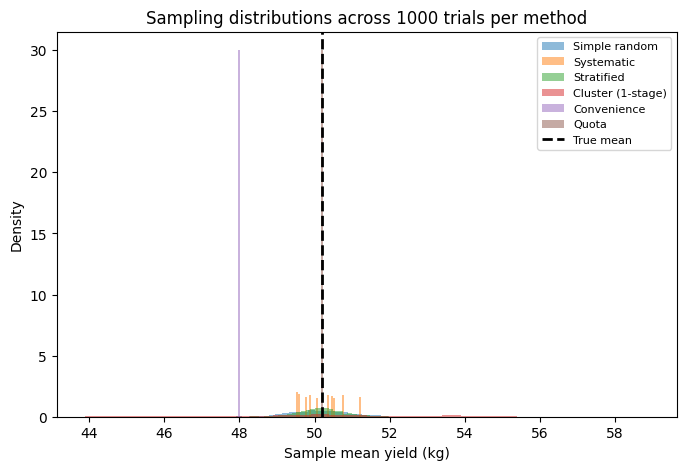

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
for name, means in methods.items():
    ax.hist(means, bins=30, alpha=0.5, label=name, density=True)
ax.axvline(POP_MEAN, color="black", linestyle="--", linewidth=2, label="True mean")
ax.set_xlabel("Sample mean yield (kg)")
ax.set_ylabel("Density")
ax.set_title(f"Sampling distributions across {N_TRIALS} trials per method")
ax.legend(fontsize=8)
plt.show()


**What to look for:**

- Simple random, stratified, and systematic sampling should all be centered
  very close to the true mean (roughly zero bias) because every plant has a
  known, non-zero chance of selection.
- Stratified sampling typically has the **smallest spread** — it removes
  between-plot variation from the sampling error entirely, matching the
  book's claim that stratified sampling "better represents the population...
  and reduces sample selection bias."
- Cluster sampling is unbiased **on average**, but has much **higher
  variance**, because entire clusters (which sit inside a single plot) swing
  the estimate up or down together.
- Convenience sampling is *clearly* off-center — that's bias, not
  randomness, and no amount of repetition fixes it.
- Quota sampling is closer to the truth than convenience sampling (because
  it fixes the plot proportions) but is still not a probability sample.


## 8. Preview: from a single sample to a confidence interval

In practice you only get **one** sample, not a thousand. Chapters 2 and 3 of
the book build up the machinery for turning that one sample into a
statement about the population, using a **critical value** and a
**test statistic**. Here is a first look, using a 95% confidence interval
for the mean based on a single stratified sample.


In [15]:
from scipy import stats

one_sample = stratified_sample(population, "plot", frac, rng)
x_bar = one_sample["yield_kg"].mean()
s = one_sample["yield_kg"].std(ddof=1)
n_obs = len(one_sample)

alpha = 0.05
t_crit = stats.t.ppf(1 - alpha / 2, df=n_obs - 1)  # two-tailed critical value
margin = t_crit * s / np.sqrt(n_obs)

ci_low, ci_high = x_bar - margin, x_bar + margin
print(f"Sample mean:        {x_bar:.3f} kg")
print(f"Critical value (t): {t_crit:.3f}")
print(f"95% CI:              ({ci_low:.3f}, {ci_high:.3f}) kg")
print(f"True population mean {POP_MEAN:.3f} kg inside interval? "
      f"{ci_low <= POP_MEAN <= ci_high}")


Sample mean:        49.834 kg
Critical value (t): 1.987
95% CI:              (48.065, 51.602) kg
True population mean 50.211 kg inside interval? True


In [16]:
# Because we can simulate, we can also check the interval's *coverage*:
# across many stratified samples, roughly 95% of 95% CIs should contain
# the true mean. This is the frequentist definition of "confidence."
hits = 0
for _ in range(500):
    s = stratified_sample(population, "plot", frac, rng)
    xb, sd, nobs = s["yield_kg"].mean(), s["yield_kg"].std(ddof=1), len(s)
    tcrit = stats.t.ppf(0.975, df=nobs - 1)
    m = tcrit * sd / np.sqrt(nobs)
    if xb - m <= POP_MEAN <= xb + m:
        hits += 1

print(f"Empirical coverage: {hits/500:.1%} (target: 95%)")


Empirical coverage: 98.6% (target: 95%)


## 9. Wrap-up

| Method | Every unit has known chance? | Typical bias | Typical variance | Formal inference valid? |
|---|---|---|---|---|
| Simple random | Yes | ~0 | Baseline | Yes |
| Systematic | Yes (if no hidden periodicity) | ~0, *unless* population order aligns with interval | Similar to SRS | Yes, with caution |
| Stratified | Yes | ~0 | Usually lower than SRS | Yes |
| Cluster | Yes | ~0 | Usually higher than SRS | Yes, with cluster-aware variance formulas |
| Convenience | No | Often large | Understated (looks precise, isn't accurate) | No |
| Quota | No | Smaller than convenience, still present | Understated | No |

Continue to the **skeleton notebook** to rebuild this lab from scratch, the
**cheat sheet** for a fast reference, and the **template notebook** the next
time you need to sample from a real dataset.
